# Visualise global and spatial effects of best environmental predictors


### imports

In [1]:

import sys
import os
import glob

import numpy as np
import pandas as pd
import xarray as xr

import matplotlib.pyplot as plt
from matplotlib import ticker
from matplotlib.gridspec import GridSpec
import matplotlib.colors as mcolors
import cmocean.cm as cmo
from cmocean.tools import lighten
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# statistics
import scipy as sci

# regridding package
import xesmf as xe

# Copernicus marine toolbox
#import copernicusmarine
#from pprint import pprint
#copernicusmarine.login()

# print versions of packages
print("python version =",sys.version[:5])
print("numpy version =", np.__version__)
print("pandas version =", pd.__version__)
print("scipy version =", sci.__version__)
print("xarray version =", xr.__version__)
print("xesmf version =", xe.__version__)
print("cartopy version =", sys.modules[ccrs.__package__].__version__)
print("matplotlib version =", sys.modules[plt.__package__].__version__)
print("cmocean version =", sys.modules[cmo.__package__].__version__)

wrkdir="/g/data/es60/SEAPODYM/pearse_GAMs"
os.chdir(wrkdir)
os.getcwd()


python version = 3.10.
numpy version = 2.2.5
pandas version = 2.3.3
scipy version = 1.15.3
xarray version = 2025.4.0
xesmf version = 0.8.10
cartopy version = 0.24.1
matplotlib version = 3.10.6
cmocean version = v3.0.3


'/g/data/es60/SEAPODYM/pearse_GAMs'

### Load dask cluster

In [2]:
from dask.distributed import Client, LocalCluster

# Rule of thumb here:
# - 56 workers × 1 thread each (good isolation for NumPy/xarray)
# - ~8 GB per worker → 56 * 8 = 448 GB (leaves headroom for OS, Jupyter, scheduler)
cluster = LocalCluster(
    n_workers=28,
    threads_per_worker=1,
    memory_limit="8GB",
    # Optional niceties:
    dashboard_address=":8787",   # or ":0" for random free port
    processes=True,
)

client = Client(cluster)
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/8787/status,
Dashboard: /proxy/8787/status,Workers: 28
Total threads: 28,Total memory: 208.62 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:36305,Workers: 0
Dashboard: /proxy/8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:38133,Total threads: 1
Dashboard: /proxy/33689/status,Memory: 7.45 GiB
Nanny: tcp://127.0.0.1:33457,


### load the global effects

In [2]:
%%time

global_larvae_PP = pd.read_csv("gam_larvae_FS3_global_pp.csv")
global_larvae_SST = pd.read_csv("gam_larvae_FS3_global_sst.csv")
global_larvae_TL1 = pd.read_csv("gam_larvae_FS3_global_T_L1.csv")
global_larvae_OL2 = pd.read_csv("gam_larvae_FS3_global_O2_L2.csv")

global_juvenile_PP = pd.read_csv("gam_juvenile_FS3_global_pp.csv")
global_juvenile_SST = pd.read_csv("gam_juvenile_FS3_global_sst.csv")
global_juvenile_TL1 = pd.read_csv("gam_juvenile_FS3_global_T_L1.csv")
global_juvenile_OL2 = pd.read_csv("gam_juvenile_FS3_global_O2_L2.csv")

global_adult_TL1 = pd.read_csv("gam_adult_FS3_global_T_L1.csv")
global_adult_SST = pd.read_csv("gam_adult_FS3_global_sst.csv")
global_adult_OL2 = pd.read_csv("gam_adult_FS3_global_O2_L2.csv")
global_adult_TL2 = pd.read_csv("gam_adult_FS3_global_T_L2.csv")

def conv(y):
    x = y + 0.0
    x = np.sign(y) * (10**(np.abs(y)) - 1.0)
    return x

global_larvae_PP['effect'] = conv(global_larvae_PP['effect'])
global_larvae_SST['effect'] = conv(global_larvae_SST['effect'])
global_larvae_TL1['effect'] = conv(global_larvae_TL1['effect'])
global_larvae_OL2['effect'] = conv(global_larvae_OL2['effect'])

global_juvenile_PP['effect'] = conv(global_juvenile_PP['effect'])
global_juvenile_SST['effect'] = conv(global_juvenile_SST['effect'])
global_juvenile_TL1['effect'] = conv(global_juvenile_TL1['effect'])
global_juvenile_OL2['effect'] = conv(global_juvenile_OL2['effect'])

global_adult_TL1['effect'] = conv(global_adult_TL1['effect']) * 1e3
global_adult_SST['effect'] = conv(global_adult_SST['effect']) * 1e3
global_adult_OL2['effect'] = conv(global_adult_OL2['effect']) * 1e3
global_adult_TL2['effect'] = conv(global_adult_TL2['effect']) * 1e3

global_larvae_PP['se'] = conv(global_larvae_PP['se'])
global_larvae_SST['se'] = conv(global_larvae_SST['se'])
global_larvae_TL1['se'] = conv(global_larvae_TL1['se'])
global_larvae_OL2['se'] = conv(global_larvae_OL2['se'])

global_juvenile_PP['se'] = conv(global_juvenile_PP['se'])
global_juvenile_SST['se'] = conv(global_juvenile_SST['se'])
global_juvenile_TL1['se'] = conv(global_juvenile_TL1['se'])
global_juvenile_OL2['se'] = conv(global_juvenile_OL2['se'])

global_adult_TL1['se'] = conv(global_adult_TL1['se']) * 1e3
global_adult_SST['se'] = conv(global_adult_SST['se']) * 1e3
global_adult_OL2['se'] = conv(global_adult_OL2['se']) * 1e3
global_adult_TL2['se'] = conv(global_adult_TL2['se']) * 1e3


CPU times: user 58.6 ms, sys: 218 ms, total: 277 ms
Wall time: 4.7 s


### plot the global relationships

CPU times: user 235 ms, sys: 15.8 ms, total: 250 ms
Wall time: 249 ms


Text(0.035, 0.965, 'l')

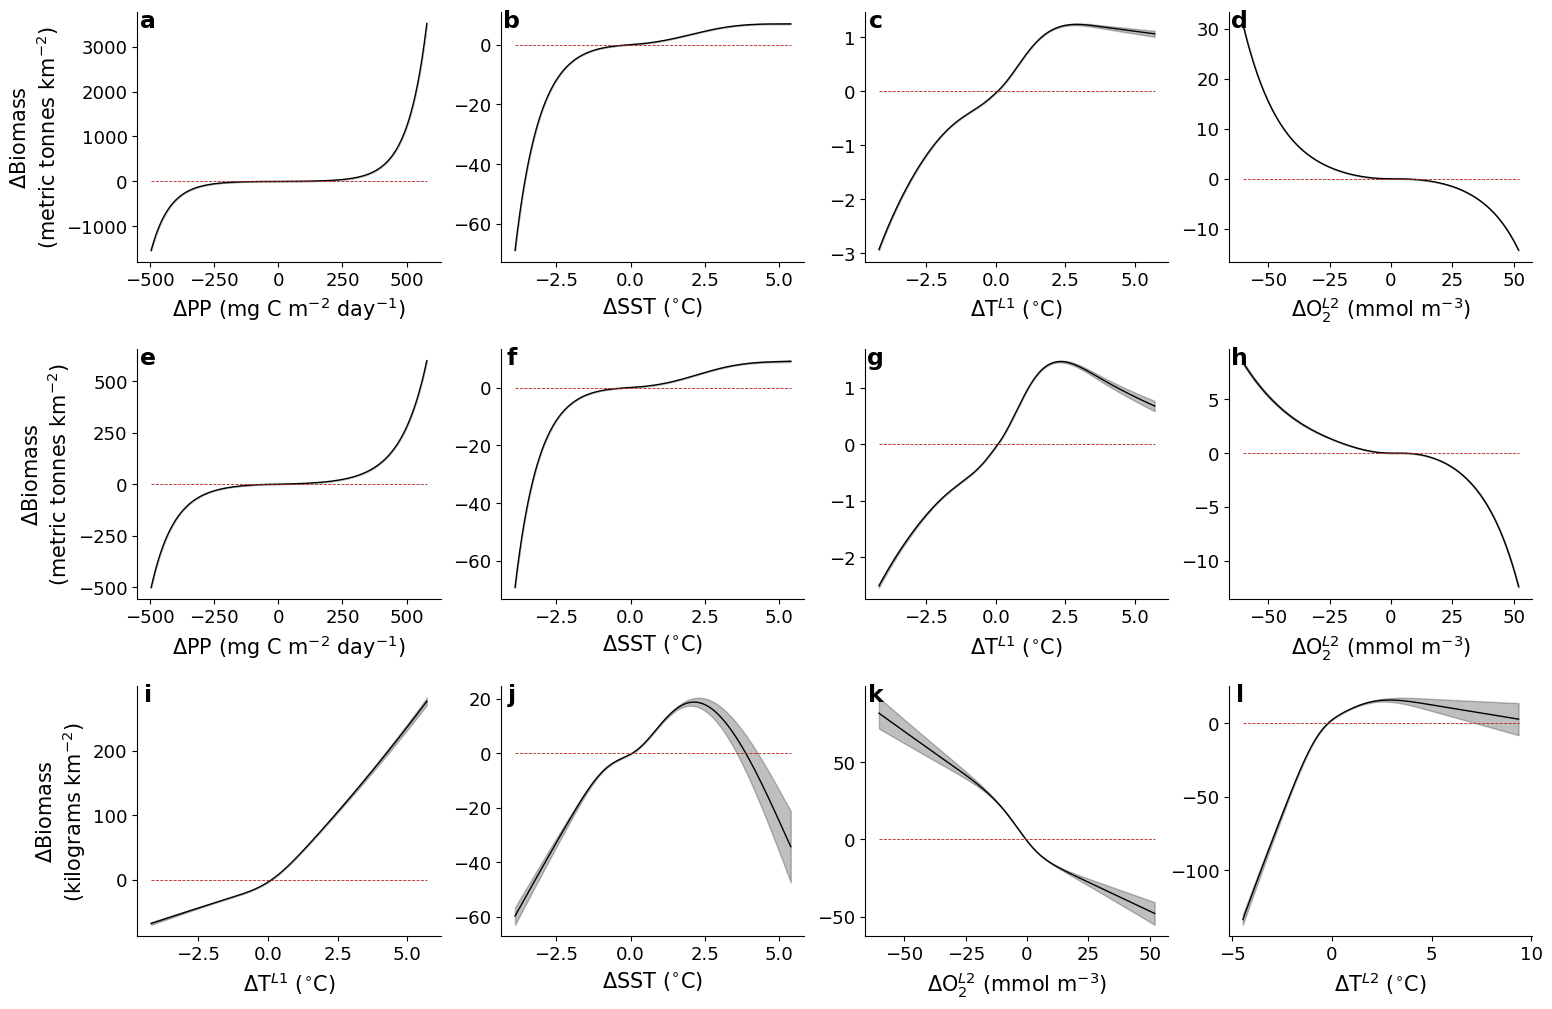

In [4]:
%%time

fstic = 13
fslab = 15

cols = ['k', 'firebrick']
lwid = [1.0, 0.6]
lsty = ['-', '--']
alfs = [1.0, 0.25]

fig = plt.figure(figsize=(18,12))
gs = GridSpec(3,4)

ax1 = plt.subplot(gs[0,0])
ax2 = plt.subplot(gs[0,1])
ax3 = plt.subplot(gs[0,2])
ax4 = plt.subplot(gs[0,3])
ax5 = plt.subplot(gs[1,0])
ax6 = plt.subplot(gs[1,1])
ax7 = plt.subplot(gs[1,2])
ax8 = plt.subplot(gs[1,3])
ax9 = plt.subplot(gs[2,0])
ax10 = plt.subplot(gs[2,1])
ax11 = plt.subplot(gs[2,2])
ax12 = plt.subplot(gs[2,3])

ax1.spines[['top','right']].set_visible(False)
ax2.spines[['top','right']].set_visible(False)
ax3.spines[['top','right']].set_visible(False)
ax4.spines[['top','right']].set_visible(False)
ax5.spines[['top','right']].set_visible(False)
ax6.spines[['top','right']].set_visible(False)
ax7.spines[['top','right']].set_visible(False)
ax8.spines[['top','right']].set_visible(False)
ax9.spines[['top','right']].set_visible(False)
ax10.spines[['top','right']].set_visible(False)
ax11.spines[['top','right']].set_visible(False)
ax12.spines[['top','right']].set_visible(False)
ax1.tick_params(labelsize=fstic)
ax2.tick_params(labelsize=fstic)
ax3.tick_params(labelsize=fstic)
ax4.tick_params(labelsize=fstic)
ax5.tick_params(labelsize=fstic)
ax6.tick_params(labelsize=fstic)
ax7.tick_params(labelsize=fstic)
ax8.tick_params(labelsize=fstic)
ax9.tick_params(labelsize=fstic)
ax10.tick_params(labelsize=fstic)
ax11.tick_params(labelsize=fstic)
ax12.tick_params(labelsize=fstic)

ax1.plot(global_larvae_PP['x']*12, global_larvae_PP['effect'], color=cols[0], linewidth=lwid[0], linestyle=lsty[0], alpha=alfs[0])
ax1.fill_between(global_larvae_PP['x']*12, global_larvae_PP['effect'] - global_larvae_PP['se'], 
                 global_larvae_PP['effect'] + global_larvae_PP['se'], color=cols[0], alpha=alfs[1])
ax1.plot(global_larvae_PP['x']*12, global_larvae_PP['x']*0.0, color=cols[1], linewidth=lwid[1], linestyle=lsty[1], alpha=alfs[0])

ax2.plot(global_larvae_SST['x'], global_larvae_SST['effect'], color=cols[0], linewidth=lwid[0], linestyle=lsty[0], alpha=alfs[0])
ax2.fill_between(global_larvae_SST['x'], global_larvae_SST['effect'] - global_larvae_SST['se'], 
                 global_larvae_SST['effect'] + global_larvae_SST['se'], color=cols[0], alpha=alfs[1])
ax2.plot(global_larvae_SST['x'], global_larvae_SST['x']*0.0, color=cols[1], linewidth=lwid[1], linestyle=lsty[1], alpha=alfs[0])

ax3.plot(global_larvae_TL1['x'], global_larvae_TL1['effect'], color=cols[0], linewidth=lwid[0], linestyle=lsty[0], alpha=alfs[0])
ax3.fill_between(global_larvae_TL1['x'], global_larvae_TL1['effect'] - global_larvae_TL1['se'], 
                 global_larvae_TL1['effect'] + global_larvae_TL1['se'], color=cols[0], alpha=alfs[1])
ax3.plot(global_larvae_TL1['x'], global_larvae_TL1['x']*0.0, color=cols[1], linewidth=lwid[1], linestyle=lsty[1], alpha=alfs[0])

ax4.plot(global_larvae_OL2['x']*44.61, global_larvae_OL2['effect'], color=cols[0], linewidth=lwid[0], linestyle=lsty[0], alpha=alfs[0])
ax4.fill_between(global_larvae_OL2['x']*44.61, global_larvae_OL2['effect'] - global_larvae_OL2['se'], 
                 global_larvae_OL2['effect'] + global_larvae_OL2['se'], color=cols[0], alpha=alfs[1])
ax4.plot(global_larvae_OL2['x']*44.61, global_larvae_OL2['x']*0.0, color=cols[1], linewidth=lwid[1], linestyle=lsty[1], alpha=alfs[0])


ax5.plot(global_juvenile_PP['x']*12, global_juvenile_PP['effect'], color=cols[0], linewidth=lwid[0], linestyle=lsty[0], alpha=alfs[0])
ax5.fill_between(global_juvenile_PP['x']*12, global_juvenile_PP['effect'] - global_juvenile_PP['se'], 
                 global_juvenile_PP['effect'] + global_juvenile_PP['se'], color=cols[0], alpha=alfs[1])
ax5.plot(global_juvenile_PP['x']*12, global_juvenile_PP['x']*0.0, color=cols[1], linewidth=lwid[1], linestyle=lsty[1], alpha=alfs[0])

ax6.plot(global_juvenile_SST['x'], global_juvenile_SST['effect'], color=cols[0], linewidth=lwid[0], linestyle=lsty[0], alpha=alfs[0])
ax6.fill_between(global_juvenile_SST['x'], global_juvenile_SST['effect'] - global_juvenile_SST['se'], 
                 global_juvenile_SST['effect'] + global_juvenile_SST['se'], color=cols[0], alpha=alfs[1])
ax6.plot(global_juvenile_SST['x'], global_juvenile_SST['x']*0.0, color=cols[1], linewidth=lwid[1], linestyle=lsty[1], alpha=alfs[0])

ax7.plot(global_juvenile_TL1['x'], global_juvenile_TL1['effect'], color=cols[0], linewidth=lwid[0], linestyle=lsty[0], alpha=alfs[0])
ax7.fill_between(global_juvenile_TL1['x'], global_juvenile_TL1['effect'] - global_juvenile_TL1['se'], 
                 global_juvenile_TL1['effect'] + global_juvenile_TL1['se'], color=cols[0], alpha=alfs[1])
ax7.plot(global_juvenile_TL1['x'], global_juvenile_TL1['x']*0.0, color=cols[1], linewidth=lwid[1], linestyle=lsty[1], alpha=alfs[0])

ax8.plot(global_juvenile_OL2['x']*44.61, global_juvenile_OL2['effect'], color=cols[0], linewidth=lwid[0], linestyle=lsty[0], alpha=alfs[0])
ax8.fill_between(global_juvenile_OL2['x']*44.61, global_juvenile_OL2['effect'] - global_juvenile_OL2['se'], 
                 global_juvenile_OL2['effect'] + global_juvenile_OL2['se'], color=cols[0], alpha=alfs[1])
ax8.plot(global_juvenile_OL2['x']*44.61, global_juvenile_OL2['x']*0.0, color=cols[1], linewidth=lwid[1], linestyle=lsty[1], alpha=alfs[0])


ax9.plot(global_adult_TL1['x'], global_adult_TL1['effect'], color=cols[0], linewidth=lwid[0], linestyle=lsty[0], alpha=alfs[0])
ax9.fill_between(global_adult_TL1['x'], global_adult_TL1['effect'] - global_adult_TL1['se'], 
                 global_adult_TL1['effect'] + global_adult_TL1['se'], color=cols[0], alpha=alfs[1])
ax9.plot(global_adult_TL1['x'],global_adult_TL1['x']*0.0, color=cols[1], linewidth=lwid[1], linestyle=lsty[1], alpha=alfs[0])

ax10.plot(global_adult_SST['x'], global_adult_SST['effect'], color=cols[0], linewidth=lwid[0], linestyle=lsty[0], alpha=alfs[0])
ax10.fill_between(global_adult_SST['x'], global_adult_SST['effect'] - global_adult_SST['se'], 
                 global_adult_SST['effect'] + global_adult_SST['se'], color=cols[0], alpha=alfs[1])
ax10.plot(global_adult_SST['x'],global_adult_SST['x']*0.0, color=cols[1], linewidth=lwid[1], linestyle=lsty[1], alpha=alfs[0])

ax11.plot(global_adult_OL2['x']*44.61, global_adult_OL2['effect'], color=cols[0], linewidth=lwid[0], linestyle=lsty[0], alpha=alfs[0])
ax11.fill_between(global_adult_OL2['x']*44.61, global_adult_OL2['effect'] - global_adult_OL2['se'], 
                 global_adult_OL2['effect'] + global_adult_OL2['se'], color=cols[0], alpha=alfs[1])
ax11.plot(global_adult_OL2['x']*44.61,global_adult_OL2['x']*0.0, color=cols[1], linewidth=lwid[1], linestyle=lsty[1], alpha=alfs[0])

ax12.plot(global_adult_TL2['x'], global_adult_TL2['effect'], color=cols[0], linewidth=lwid[0], linestyle=lsty[0], alpha=alfs[0])
ax12.fill_between(global_adult_TL2['x'], global_adult_TL2['effect'] - global_adult_TL2['se'], 
                 global_adult_TL2['effect'] + global_adult_TL2['se'], color=cols[0], alpha=alfs[1])
ax12.plot(global_adult_TL2['x'],global_adult_TL2['x']*0.0, color=cols[1], linewidth=lwid[1], linestyle=lsty[1], alpha=alfs[0])

ax1.set_xlabel("$\Delta$PP (mg C m$^{-2}$ day$^{-1}$)", fontsize=fslab)
ax2.set_xlabel("$\Delta$SST ($^{\circ}$C)", fontsize=fslab)
ax3.set_xlabel("$\Delta$T$^{L1}$ ($^{\circ}$C)", fontsize=fslab)
ax4.set_xlabel("$\Delta$O$_2^{L2}$ (mmol m$^{-3}$)", fontsize=fslab)

ax5.set_xlabel("$\Delta$PP (mg C m$^{-2}$ day$^{-1}$)", fontsize=fslab)
ax6.set_xlabel("$\Delta$SST ($^{\circ}$C)", fontsize=fslab)
ax7.set_xlabel("$\Delta$T$^{L1}$ ($^{\circ}$C)", fontsize=fslab)
ax8.set_xlabel("$\Delta$O$_2^{L2}$ (mmol m$^{-3}$)", fontsize=fslab)

ax9.set_xlabel("$\Delta$T$^{L1}$ ($^{\circ}$C)", fontsize=fslab)
ax10.set_xlabel("$\Delta$SST ($^{\circ}$C)", fontsize=fslab)
ax11.set_xlabel("$\Delta$O$_2^{L2}$ (mmol m$^{-3}$)", fontsize=fslab)
ax12.set_xlabel("$\Delta$T$^{L2}$ ($^{\circ}$C)", fontsize=fslab)

plt.subplots_adjust(hspace=0.35)

ax1.set_ylabel("$\Delta$Biomass\n(metric tonnes km$^{-2}$)", fontsize=fslab)
ax5.set_ylabel("$\Delta$Biomass\n(metric tonnes km$^{-2}$)", fontsize=fslab)
ax9.set_ylabel("$\Delta$Biomass\n(kilograms km$^{-2}$)", fontsize=fslab)

#ax1.text(-0.2,0.5, "$\Delta$Biomass (Kilotonnes km$^{-2}$)", transform=ax3.transAxes, fontsize=fslab, va='center', ha='center', rotation=90)

xx = 0.035; yy = 0.965
plt.text(xx,yy,"a", fontweight="bold", fontsize=fslab+2, va='center', ha='center', transform=ax1.transAxes)
plt.text(xx,yy,"b", fontweight="bold", fontsize=fslab+2, va='center', ha='center', transform=ax2.transAxes)
plt.text(xx,yy,"c", fontweight="bold", fontsize=fslab+2, va='center', ha='center', transform=ax3.transAxes)
plt.text(xx,yy,"d", fontweight="bold", fontsize=fslab+2, va='center', ha='center', transform=ax4.transAxes)
plt.text(xx,yy,"e", fontweight="bold", fontsize=fslab+2, va='center', ha='center', transform=ax5.transAxes)
plt.text(xx,yy,"f", fontweight="bold", fontsize=fslab+2, va='center', ha='center', transform=ax6.transAxes)
plt.text(xx,yy,"g", fontweight="bold", fontsize=fslab+2, va='center', ha='center', transform=ax7.transAxes)
plt.text(xx,yy,"h", fontweight="bold", fontsize=fslab+2, va='center', ha='center', transform=ax8.transAxes)
plt.text(xx,yy,"i", fontweight="bold", fontsize=fslab+2, va='center', ha='center', transform=ax9.transAxes)
plt.text(xx,yy,"j", fontweight="bold", fontsize=fslab+2, va='center', ha='center', transform=ax10.transAxes)
plt.text(xx,yy,"k", fontweight="bold", fontsize=fslab+2, va='center', ha='center', transform=ax11.transAxes)
plt.text(xx,yy,"l", fontweight="bold", fontsize=fslab+2, va='center', ha='center', transform=ax12.transAxes)



In [5]:
fig.savefig("./figures/Global_effects.png", dpi=300, bbox_inches='tight')
fig.savefig("./figures/Global_effects_transparent.png", dpi=300, bbox_inches='tight', transparent=True)


### Load the spatial effects data

In [6]:
%%time

spatial_larvae_PP = pd.read_csv("gam_larvae_FS3_spatial_pp_sd.csv")
spatial_larvae_SST = pd.read_csv("gam_larvae_FS3_spatial_sst_sd.csv")
spatial_larvae_TL1 = pd.read_csv("gam_larvae_FS3_spatial_T_L1_sd.csv")
spatial_larvae_OL2 = pd.read_csv("gam_larvae_FS3_spatial_O2_L2_sd.csv")

spatial_juvenile_PP = pd.read_csv("gam_juvenile_FS3_spatial_pp_sd.csv")
spatial_juvenile_SST = pd.read_csv("gam_juvenile_FS3_spatial_sst_sd.csv")
spatial_juvenile_TL1 = pd.read_csv("gam_juvenile_FS3_spatial_T_L1_sd.csv")
spatial_juvenile_OL2 = pd.read_csv("gam_juvenile_FS3_spatial_O2_L2_sd.csv")

spatial_adult_TL1 = pd.read_csv("gam_adult_FS3_spatial_T_L1_sd.csv")
spatial_adult_SST = pd.read_csv("gam_adult_FS3_spatial_sst_sd.csv")
spatial_adult_OL2 = pd.read_csv("gam_adult_FS3_spatial_O2_L2_sd.csv")
spatial_adult_TL2 = pd.read_csv("gam_adult_FS3_spatial_T_L2_sd.csv")

spatialP_larvae_PP = pd.read_csv("gam_larvae_FS3_spatial_pp_5mmolCm2day.csv")
spatialP_larvae_SST = pd.read_csv("gam_larvae_FS3_spatial_sst_0.5degC.csv")
spatialP_larvae_TL1 = pd.read_csv("gam_larvae_FS3_spatial_T_L1_0.5degC.csv")
spatialP_larvae_OL2 = pd.read_csv("gam_larvae_FS3_spatial_O2_L2_10mmolm3.csv")

spatialP_juvenile_PP = pd.read_csv("gam_juvenile_FS3_spatial_pp_5mmolCm2day.csv")
spatialP_juvenile_SST = pd.read_csv("gam_juvenile_FS3_spatial_sst_0.5degC.csv")
spatialP_juvenile_TL1 = pd.read_csv("gam_juvenile_FS3_spatial_T_L1_0.5degC.csv")
spatialP_juvenile_OL2 = pd.read_csv("gam_juvenile_FS3_spatial_O2_L2_10mmolm3.csv")

spatialP_adult_TL1 = pd.read_csv("gam_adult_FS3_spatial_T_L1_0.5degC.csv")
spatialP_adult_SST = pd.read_csv("gam_adult_FS3_spatial_sst_0.5degC.csv")
spatialP_adult_OL2 = pd.read_csv("gam_adult_FS3_spatial_O2_L2_10mmolm3.csv")
spatialP_adult_TL2 = pd.read_csv("gam_adult_FS3_spatial_T_L2_0.5degC.csv")

def conv(y):
    x = y + 0.0
    x = np.sign(y) * (10**(np.abs(y)) - 1.0)
    return x

spatial_larvae_PP['delta_eff'] = conv(spatial_larvae_PP['delta_eff'])
spatial_larvae_SST['delta_eff'] = conv(spatial_larvae_SST['delta_eff'])
spatial_larvae_TL1['delta_eff'] = conv(spatial_larvae_TL1['delta_eff'])
spatial_larvae_OL2['delta_eff'] = conv(spatial_larvae_OL2['delta_eff'])

spatial_juvenile_PP['delta_eff'] = conv(spatial_juvenile_PP['delta_eff'])
spatial_juvenile_SST['delta_eff'] = conv(spatial_juvenile_SST['delta_eff'])
spatial_juvenile_TL1['delta_eff'] = conv(spatial_juvenile_TL1['delta_eff'])
spatial_juvenile_OL2['delta_eff'] = conv(spatial_juvenile_OL2['delta_eff'])

spatial_adult_TL1['delta_eff'] = conv(spatial_adult_TL1['delta_eff']) * 1e3
spatial_adult_SST['delta_eff'] = conv(spatial_adult_SST['delta_eff']) * 1e3
spatial_adult_OL2['delta_eff'] = conv(spatial_adult_OL2['delta_eff']) * 1e3
spatial_adult_TL2['delta_eff'] = conv(spatial_adult_TL2['delta_eff']) * 1e3

spatialP_larvae_PP['delta_eff'] = conv(spatialP_larvae_PP['delta_eff'])
spatialP_larvae_SST['delta_eff'] = conv(spatialP_larvae_SST['delta_eff'])
spatialP_larvae_TL1['delta_eff'] = conv(spatialP_larvae_TL1['delta_eff'])
spatialP_larvae_OL2['delta_eff'] = conv(spatialP_larvae_OL2['delta_eff'])

spatialP_juvenile_PP['delta_eff'] = conv(spatialP_juvenile_PP['delta_eff'])
spatialP_juvenile_SST['delta_eff'] = conv(spatialP_juvenile_SST['delta_eff'])
spatialP_juvenile_TL1['delta_eff'] = conv(spatialP_juvenile_TL1['delta_eff'])
spatialP_juvenile_OL2['delta_eff'] = conv(spatialP_juvenile_OL2['delta_eff'])

spatialP_adult_TL1['delta_eff'] = conv(spatialP_adult_TL1['delta_eff']) * 1e3
spatialP_adult_SST['delta_eff'] = conv(spatialP_adult_SST['delta_eff']) * 1e3
spatialP_adult_OL2['delta_eff'] = conv(spatialP_adult_OL2['delta_eff']) * 1e3
spatialP_adult_TL2['delta_eff'] = conv(spatialP_adult_TL2['delta_eff']) * 1e3

lons = spatial_adult_TL1['lon']
lats = spatial_adult_TL1['lat']
seasons = spatial_adult_TL1['season_num']

spatial_adult_TL1


CPU times: user 2.12 s, sys: 527 ms, total: 2.65 s
Wall time: 10.6 s


,lon,lat,season_num,delta_mult,delta_value,delta_eff
0,120.5,-0.5,2,-2,NaN,NaN
1,120.5,-0.5,4,-2,NaN,NaN
2,120.5,-0.5,1,-2,NaN,NaN
3,120.5,-0.5,3,-2,NaN,NaN
4,120.5,-1.5,1,-2,NaN,NaN
...,...,...,...,...,...,...
83195,249.5,8.5,3,2,1.665791,21.438429
83196,249.5,9.5,4,2,1.663338,39.978059
83197,249.5,9.5,3,2,1.663338,39.978059
83198,249.5,9.5,2,2,1.663338,39.978059


In [7]:
spatialP_juvenile_PP

,lon,lat,season_num,delta_mult,delta_value,delta_eff
0,120.5,-19.5,1,-2,-10,-4.143628
1,121.5,-19.5,1,-2,-10,-3.848255
2,122.5,-19.5,1,-2,-10,-3.569936
3,123.5,-19.5,1,-2,-10,-3.307825
4,124.5,-19.5,1,-2,-10,-3.061162
...,...,...,...,...,...,...
83195,245.5,19.5,4,2,10,10.249110
83196,246.5,19.5,4,2,10,10.359284
83197,247.5,19.5,4,2,10,10.472606
83198,248.5,19.5,4,2,10,10.588187


### turn the pandas Dataframe into an xarray Dataarray

In [8]:
%%time

ds_larvae_PP = (
    spatial_larvae_PP
    .set_index(['lon', 'lat', 'season_num', 'delta_mult'])
    .to_xarray()
)

ds_larvae_SST = (
    spatial_larvae_SST
    .set_index(['lon', 'lat', 'season_num', 'delta_mult'])
    .to_xarray()
)

ds_larvae_TL1 = (
    spatial_larvae_TL1
    .set_index(['lon', 'lat', 'season_num', 'delta_mult'])
    .to_xarray()
)

ds_larvae_OL2 = (
    spatial_larvae_OL2
    .set_index(['lon', 'lat', 'season_num', 'delta_mult'])
    .to_xarray()
)

ds_larvae_perturb_PP = (
    spatialP_larvae_PP
    .set_index(['lon', 'lat', 'season_num', 'delta_mult'])
    .to_xarray()
)

ds_larvae_perturb_SST = (
    spatialP_larvae_SST
    .set_index(['lon', 'lat', 'season_num', 'delta_mult'])
    .to_xarray()
)

ds_larvae_perturb_TL1 = (
    spatialP_larvae_TL1
    .set_index(['lon', 'lat', 'season_num', 'delta_mult'])
    .to_xarray()
)

ds_larvae_perturb_OL2 = (
    spatialP_larvae_OL2
    .set_index(['lon', 'lat', 'season_num', 'delta_mult'])
    .to_xarray()
)

lons = ds_larvae_TL1.coords['lon']
lats = ds_larvae_TL1.coords['lat']

ds_larvae_TL1


CPU times: user 290 ms, sys: 4.01 ms, total: 294 ms
Wall time: 292 ms


<xarray.Dataset> Size: 1MB
Dimensions:      (lon: 130, lat: 40, season_num: 4, delta_mult: 4)
Coordinates:
  * lon          (lon) float64 1kB 120.5 121.5 122.5 123.5 ... 247.5 248.5 249.5
  * lat          (lat) float64 320B -19.5 -18.5 -17.5 -16.5 ... 17.5 18.5 19.5
  * season_num   (season_num) int64 32B 1 2 3 4
  * delta_mult   (delta_mult) int64 32B -2 -1 1 2
Data variables:
    delta_value  (lon, lat, season_num, delta_mult) float64 666kB -1.007 ... ...
    delta_eff    (lon, lat, season_num, delta_mult) float64 666kB 18.91 ... -...

In [9]:
%%time

ds_juvenile_PP = (
    spatial_juvenile_PP
    .set_index(['lon', 'lat', 'season_num', 'delta_mult'])
    .to_xarray()
)

ds_juvenile_SST = (
    spatial_juvenile_SST
    .set_index(['lon', 'lat', 'season_num', 'delta_mult'])
    .to_xarray()
)

ds_juvenile_TL1 = (
    spatial_juvenile_TL1
    .set_index(['lon', 'lat', 'season_num', 'delta_mult'])
    .to_xarray()
)

ds_juvenile_OL2 = (
    spatial_juvenile_OL2
    .set_index(['lon', 'lat', 'season_num', 'delta_mult'])
    .to_xarray()
)

ds_juvenile_perturb_PP = (
    spatialP_juvenile_PP
    .set_index(['lon', 'lat', 'season_num', 'delta_mult'])
    .to_xarray()
)

ds_juvenile_perturb_SST = (
    spatialP_juvenile_SST
    .set_index(['lon', 'lat', 'season_num', 'delta_mult'])
    .to_xarray()
)

ds_juvenile_perturb_TL1 = (
    spatialP_juvenile_TL1
    .set_index(['lon', 'lat', 'season_num', 'delta_mult'])
    .to_xarray()
)

ds_juvenile_perturb_OL2 = (
    spatialP_juvenile_OL2
    .set_index(['lon', 'lat', 'season_num', 'delta_mult'])
    .to_xarray()
)
lons = ds_juvenile_TL1.coords['lon']
lats = ds_juvenile_TL1.coords['lat']

ds_juvenile_TL1

CPU times: user 180 ms, sys: 5.92 ms, total: 186 ms
Wall time: 184 ms


<xarray.Dataset> Size: 1MB
Dimensions:      (lon: 130, lat: 40, season_num: 4, delta_mult: 4)
Coordinates:
  * lon          (lon) float64 1kB 120.5 121.5 122.5 123.5 ... 247.5 248.5 249.5
  * lat          (lat) float64 320B -19.5 -18.5 -17.5 -16.5 ... 17.5 18.5 19.5
  * season_num   (season_num) int64 32B 1 2 3 4
  * delta_mult   (delta_mult) int64 32B -2 -1 1 2
Data variables:
    delta_value  (lon, lat, season_num, delta_mult) float64 666kB -1.007 ... ...
    delta_eff    (lon, lat, season_num, delta_mult) float64 666kB 4.623 ... -...

In [10]:
%%time

ds_adult_TL1 = (
    spatial_adult_TL1
    .set_index(['lon', 'lat', 'season_num', 'delta_mult'])
    .to_xarray()
)

ds_adult_SST = (
    spatial_adult_SST
    .set_index(['lon', 'lat', 'season_num', 'delta_mult'])
    .to_xarray()
)

ds_adult_OL2 = (
    spatial_adult_OL2
    .set_index(['lon', 'lat', 'season_num', 'delta_mult'])
    .to_xarray()
)

ds_adult_TL2 = (
    spatial_adult_TL2
    .set_index(['lon', 'lat', 'season_num', 'delta_mult'])
    .to_xarray()
)

ds_adult_perturb_TL1 = (
    spatialP_adult_TL1
    .set_index(['lon', 'lat', 'season_num', 'delta_mult'])
    .to_xarray()
)

ds_adult_perturb_SST = (
    spatialP_adult_SST
    .set_index(['lon', 'lat', 'season_num', 'delta_mult'])
    .to_xarray()
)

ds_adult_perturb_OL2 = (
    spatialP_adult_OL2
    .set_index(['lon', 'lat', 'season_num', 'delta_mult'])
    .to_xarray()
)

ds_adult_perturb_TL2 = (
    spatialP_adult_TL2
    .set_index(['lon', 'lat', 'season_num', 'delta_mult'])
    .to_xarray()
)
lons = ds_adult_TL1.coords['lon']
lats = ds_adult_TL1.coords['lat']

ds_adult_TL1


CPU times: user 140 ms, sys: 4.23 ms, total: 144 ms
Wall time: 142 ms


<xarray.Dataset> Size: 1MB
Dimensions:      (lon: 130, lat: 40, season_num: 4, delta_mult: 4)
Coordinates:
  * lon          (lon) float64 1kB 120.5 121.5 122.5 123.5 ... 247.5 248.5 249.5
  * lat          (lat) float64 320B -19.5 -18.5 -17.5 -16.5 ... 17.5 18.5 19.5
  * season_num   (season_num) int64 32B 1 2 3 4
  * delta_mult   (delta_mult) int64 32B -2 -1 1 2
Data variables:
    delta_value  (lon, lat, season_num, delta_mult) float64 666kB -1.007 ... ...
    delta_eff    (lon, lat, season_num, delta_mult) float64 666kB -51.99 ... ...

### visualise

#### variation with + one standard deviation

/g/data/es60/pjb581/miniforge3/envs/pyEMD_env/lib/python3.10/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


CPU times: user 2.4 s, sys: 94.3 ms, total: 2.49 s
Wall time: 4.5 s


Text(0.025, 1.1, 'l')

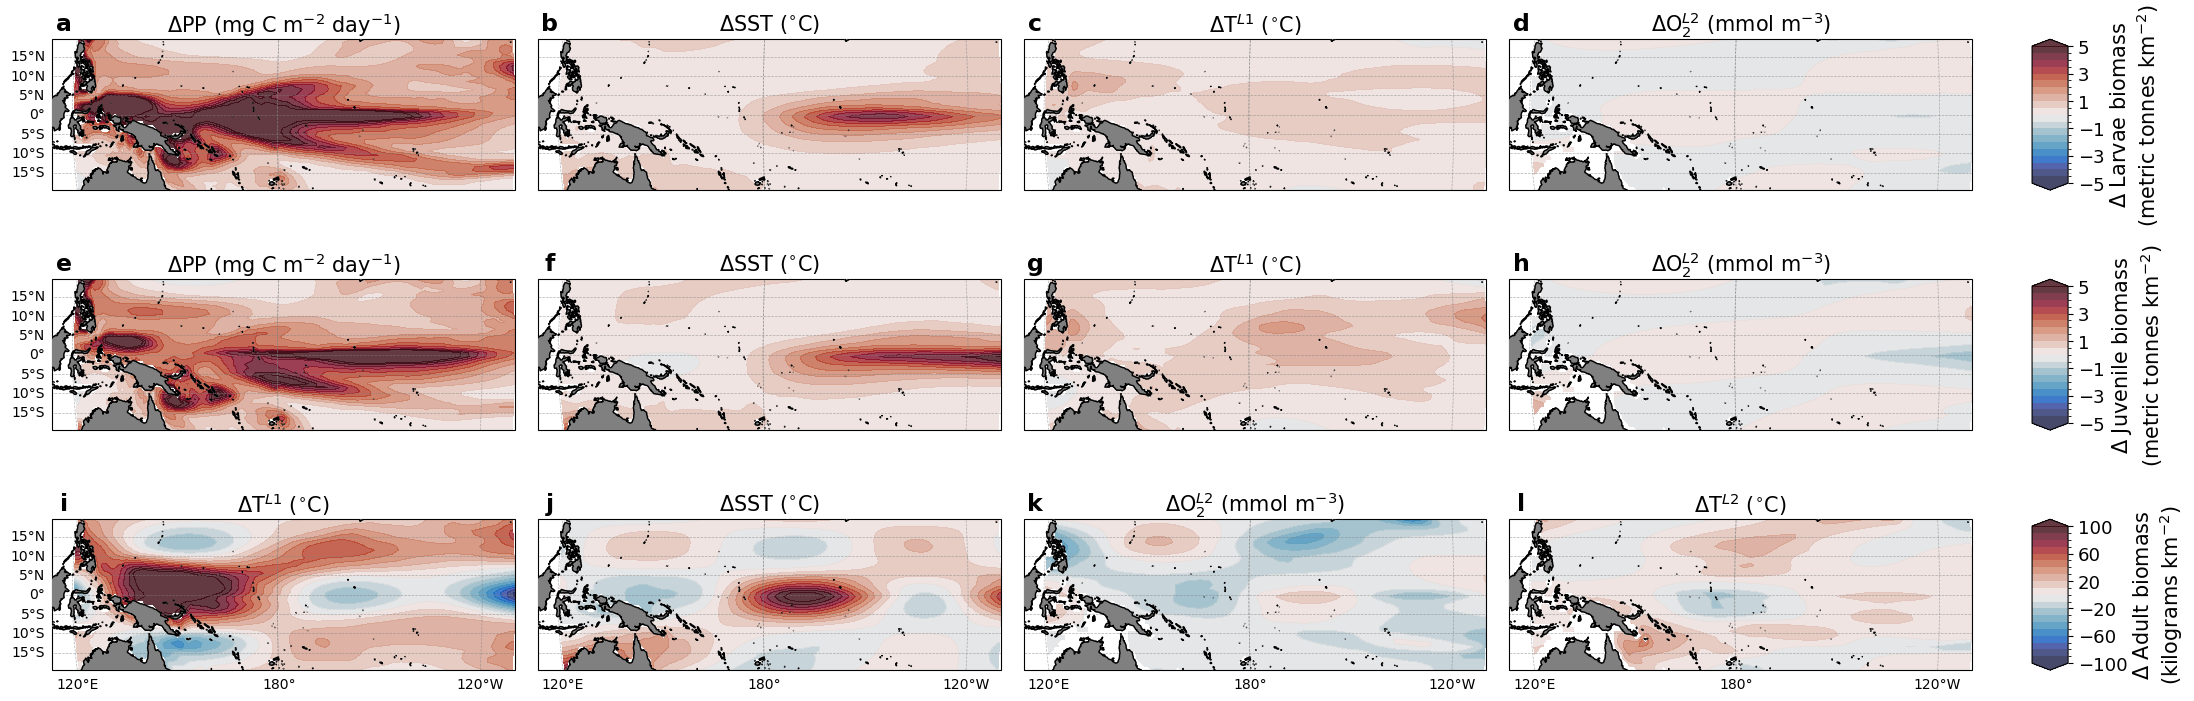

In [11]:
%%time

proj = ccrs.Robinson(central_longitude=205)

fstic = 13
fslab = 15

colmap = lighten(cmo.balance, 0.8)
levs1 = np.arange(-10,11,1)*0.5
norm1 = mcolors.BoundaryNorm(levs1, ncolors=256)
levs2 = np.arange(-10,11,1)*10
norm2 = mcolors.BoundaryNorm(levs2, ncolors=256)

fig = plt.figure(figsize=(24,8))
gs = GridSpec(3,4)

ax1 = plt.subplot(gs[0,0], projection=proj)
ax2 = plt.subplot(gs[0,1], projection=proj)
ax3 = plt.subplot(gs[0,2], projection=proj)
ax4 = plt.subplot(gs[0,3], projection=proj)
ax5 = plt.subplot(gs[1,0], projection=proj)
ax6 = plt.subplot(gs[1,1], projection=proj)
ax7 = plt.subplot(gs[1,2], projection=proj)
ax8 = plt.subplot(gs[1,3], projection=proj)
ax9 = plt.subplot(gs[2,0], projection=proj)
ax10 = plt.subplot(gs[2,1], projection=proj)
ax11 = plt.subplot(gs[2,2], projection=proj)
ax12 = plt.subplot(gs[2,3], projection=proj)

p1 = ax1.contourf(lons, lats, ds_larvae_PP['delta_eff'].sel(delta_mult=1).mean(dim='season_num').T, transform=ccrs.PlateCarree(), cmap=colmap, norm=norm1, levels=levs1, extend='both')
p2 = ax2.contourf(lons, lats, ds_larvae_SST['delta_eff'].sel(delta_mult=1).mean(dim='season_num').T, transform=ccrs.PlateCarree(), cmap=colmap, norm=norm1, levels=levs1, extend='both')
p3 = ax3.contourf(lons, lats, ds_larvae_TL1['delta_eff'].sel(delta_mult=1).mean(dim='season_num').T, transform=ccrs.PlateCarree(), cmap=colmap, norm=norm1, levels=levs1, extend='both')
p4 = ax4.contourf(lons, lats, ds_larvae_OL2['delta_eff'].sel(delta_mult=1).mean(dim='season_num').T, transform=ccrs.PlateCarree(), cmap=colmap, norm=norm1, levels=levs1, extend='both')

p5 = ax5.contourf(lons, lats, ds_juvenile_PP['delta_eff'].sel(delta_mult=1).mean(dim='season_num').T, transform=ccrs.PlateCarree(), cmap=colmap, norm=norm1, levels=levs1, extend='both')
p6 = ax6.contourf(lons, lats, ds_juvenile_SST['delta_eff'].sel(delta_mult=1).mean(dim='season_num').T, transform=ccrs.PlateCarree(), cmap=colmap, norm=norm1, levels=levs1, extend='both')
p7 = ax7.contourf(lons, lats, ds_juvenile_TL1['delta_eff'].sel(delta_mult=1).mean(dim='season_num').T, transform=ccrs.PlateCarree(), cmap=colmap, norm=norm1, levels=levs1, extend='both')
p8 = ax8.contourf(lons, lats, ds_juvenile_OL2['delta_eff'].sel(delta_mult=1).mean(dim='season_num').T, transform=ccrs.PlateCarree(), cmap=colmap, norm=norm1, levels=levs1, extend='both')

p9 = ax9.contourf(lons, lats, ds_adult_TL1['delta_eff'].sel(delta_mult=1).mean(dim='season_num').T, transform=ccrs.PlateCarree(), cmap=colmap, norm=norm2, levels=levs2, extend='both')
p10 = ax10.contourf(lons, lats, ds_adult_SST['delta_eff'].sel(delta_mult=1).mean(dim='season_num').T, transform=ccrs.PlateCarree(), cmap=colmap, norm=norm2, levels=levs2, extend='both')
p11 = ax11.contourf(lons, lats, ds_adult_OL2['delta_eff'].sel(delta_mult=1).mean(dim='season_num').T, transform=ccrs.PlateCarree(), cmap=colmap, norm=norm2, levels=levs2, extend='both')
p12 = ax12.contourf(lons, lats, ds_adult_TL2['delta_eff'].sel(delta_mult=1).mean(dim='season_num').T, transform=ccrs.PlateCarree(), cmap=colmap, norm=norm2, levels=levs2, extend='both')

ax1.add_feature(cfeature.LAND, color='grey', zorder=3)
ax1.add_feature(cfeature.COASTLINE, color='k', zorder=4)
ax2.add_feature(cfeature.LAND, color='grey', zorder=3)
ax2.add_feature(cfeature.COASTLINE, color='k', zorder=4)
ax3.add_feature(cfeature.LAND, color='grey', zorder=3)
ax3.add_feature(cfeature.COASTLINE, color='k', zorder=4)
ax4.add_feature(cfeature.LAND, color='grey', zorder=3)
ax4.add_feature(cfeature.COASTLINE, color='k', zorder=4)
ax5.add_feature(cfeature.LAND, color='grey', zorder=3)
ax5.add_feature(cfeature.COASTLINE, color='k', zorder=4)
ax6.add_feature(cfeature.LAND, color='grey', zorder=3)
ax6.add_feature(cfeature.COASTLINE, color='k', zorder=4)
ax7.add_feature(cfeature.LAND, color='grey', zorder=3)
ax7.add_feature(cfeature.COASTLINE, color='k', zorder=4)
ax8.add_feature(cfeature.LAND, color='grey', zorder=3)
ax8.add_feature(cfeature.COASTLINE, color='k', zorder=4)
ax9.add_feature(cfeature.LAND, color='grey', zorder=3)
ax9.add_feature(cfeature.COASTLINE, color='k', zorder=4)
ax10.add_feature(cfeature.LAND, color='grey', zorder=3)
ax10.add_feature(cfeature.COASTLINE, color='k', zorder=4)
ax11.add_feature(cfeature.LAND, color='grey', zorder=3)
ax11.add_feature(cfeature.COASTLINE, color='k', zorder=4)
ax12.add_feature(cfeature.LAND, color='grey', zorder=3)
ax12.add_feature(cfeature.COASTLINE, color='k', zorder=4)

gl1 = ax1.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.6, linestyle='--')
gl2 = ax2.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.6, linestyle='--')
gl3 = ax3.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.6, linestyle='--')
gl4 = ax4.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.6, linestyle='--')
gl5 = ax5.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.6, linestyle='--')
gl6 = ax6.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.6, linestyle='--')
gl7 = ax7.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.6, linestyle='--')
gl8 = ax8.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.6, linestyle='--')
gl9 = ax9.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.6, linestyle='--')
gl10 = ax10.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.6, linestyle='--')
gl11 = ax11.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.6, linestyle='--')
gl12 = ax12.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.6, linestyle='--')

gl1.top_labels = False; gl1.right_labels = False; gl1.bottom_labels = False
gl2.top_labels = False; gl2.right_labels = False; gl2.bottom_labels = False; gl2.left_labels = False
gl3.top_labels = False; gl3.right_labels = False; gl3.bottom_labels = False; gl3.left_labels = False
gl4.top_labels = False; gl4.right_labels = False; gl4.bottom_labels = False; gl4.left_labels = False
gl5.top_labels = False; gl5.right_labels = False; gl5.bottom_labels = False
gl6.top_labels = False; gl6.right_labels = False; gl6.bottom_labels = False; gl6.left_labels = False
gl7.top_labels = False; gl7.right_labels = False; gl7.bottom_labels = False; gl7.left_labels = False
gl8.top_labels = False; gl8.right_labels = False; gl8.bottom_labels = False; gl8.left_labels = False
gl9.top_labels = False; gl9.right_labels = False; 
gl10.top_labels = False; gl10.right_labels = False; gl10.left_labels = False
gl11.top_labels = False; gl11.right_labels = False; gl11.left_labels = False
gl12.top_labels = False; gl12.right_labels = False; gl12.left_labels = False

xx = 0.5; yy=1.1
plt.text(xx,yy,"$\Delta$PP (mg C m$^{-2}$ day$^{-1}$)", fontsize=fslab, ha='center', va='center', transform=ax1.transAxes)
plt.text(xx,yy,"$\Delta$SST ($^{\circ}$C)", fontsize=fslab, ha='center', va='center', transform=ax2.transAxes)
plt.text(xx,yy,"$\Delta$T$^{L1}$ ($^{\circ}$C)", fontsize=fslab, ha='center', va='center', transform=ax3.transAxes)
plt.text(xx,yy,"$\Delta$O$_2^{L2}$ (mmol m$^{-3}$)", fontsize=fslab, ha='center', va='center', transform=ax4.transAxes)

plt.text(xx,yy,"$\Delta$PP (mg C m$^{-2}$ day$^{-1}$)", fontsize=fslab, ha='center', va='center', transform=ax5.transAxes)
plt.text(xx,yy,"$\Delta$SST ($^{\circ}$C)", fontsize=fslab, ha='center', va='center', transform=ax6.transAxes)
plt.text(xx,yy,"$\Delta$T$^{L1}$ ($^{\circ}$C)", fontsize=fslab, ha='center', va='center', transform=ax7.transAxes)
plt.text(xx,yy,"$\Delta$O$_2^{L2}$ (mmol m$^{-3}$)", fontsize=fslab, ha='center', va='center', transform=ax8.transAxes)

plt.text(xx,yy,"$\Delta$T$^{L1}$ ($^{\circ}$C)", fontsize=fslab, ha='center', va='center', transform=ax9.transAxes)
plt.text(xx,yy,"$\Delta$SST ($^{\circ}$C)", fontsize=fslab, ha='center', va='center', transform=ax10.transAxes)
plt.text(xx,yy,"$\Delta$O$_2^{L2}$ (mmol m$^{-3}$)", fontsize=fslab, ha='center', va='center', transform=ax11.transAxes)
plt.text(xx,yy,"$\Delta$T$^{L2}$ ($^{\circ}$C)", fontsize=fslab, ha='center', va='center', transform=ax12.transAxes)

plt.subplots_adjust(wspace=0.05, hspace=0.0, left=0.05, right=0.85, bottom=0.05, top=0.95)

xx = 0.025
ax4pos = ax4.get_position()
ax8pos = ax8.get_position()
ax12pos = ax12.get_position()
cbax1 = fig.add_axes([ax4pos.x1 + xx, ax4pos.y0, 0.015, ax4pos.y1 - ax4pos.y0])
cbax2 = fig.add_axes([ax8pos.x1 + xx, ax8pos.y0, 0.015, ax8pos.y1 - ax8pos.y0])
cbax3 = fig.add_axes([ax12pos.x1 + xx, ax12pos.y0, 0.015, ax12pos.y1 - ax12pos.y0])

cbar1 = plt.colorbar(p1, cax=cbax1, orientation='vertical', ticks=levs1[::4])
cbar1.ax.tick_params(labelsize=fstic)
cbar1.ax.set_ylabel("$\Delta$ Larvae biomass\n(metric tonnes km$^{-2}$)", fontsize=fslab)

cbar2 = plt.colorbar(p5, cax=cbax2, orientation='vertical', ticks=levs1[::4])
cbar2.ax.tick_params(labelsize=fstic)
cbar2.ax.set_ylabel("$\Delta$ Juvenile biomass\n(metric tonnes km$^{-2}$)", fontsize=fslab)

cbar3 = plt.colorbar(p9, cax=cbax3, orientation='vertical', ticks=levs2[::4])
cbar3.ax.tick_params(labelsize=fstic)
cbar3.ax.set_ylabel("$\Delta$ Adult biomass\n(kilograms km$^{-2}$)", fontsize=fslab)

xx = 0.025; yy = 1.1
plt.text(xx,yy,"a", fontweight="bold", fontsize=fslab+2, va='center', ha='center', transform=ax1.transAxes)
plt.text(xx,yy,"b", fontweight="bold", fontsize=fslab+2, va='center', ha='center', transform=ax2.transAxes)
plt.text(xx,yy,"c", fontweight="bold", fontsize=fslab+2, va='center', ha='center', transform=ax3.transAxes)
plt.text(xx,yy,"d", fontweight="bold", fontsize=fslab+2, va='center', ha='center', transform=ax4.transAxes)
plt.text(xx,yy,"e", fontweight="bold", fontsize=fslab+2, va='center', ha='center', transform=ax5.transAxes)
plt.text(xx,yy,"f", fontweight="bold", fontsize=fslab+2, va='center', ha='center', transform=ax6.transAxes)
plt.text(xx,yy,"g", fontweight="bold", fontsize=fslab+2, va='center', ha='center', transform=ax7.transAxes)
plt.text(xx,yy,"h", fontweight="bold", fontsize=fslab+2, va='center', ha='center', transform=ax8.transAxes)
plt.text(xx,yy,"i", fontweight="bold", fontsize=fslab+2, va='center', ha='center', transform=ax9.transAxes)
plt.text(xx,yy,"j", fontweight="bold", fontsize=fslab+2, va='center', ha='center', transform=ax10.transAxes)
plt.text(xx,yy,"k", fontweight="bold", fontsize=fslab+2, va='center', ha='center', transform=ax11.transAxes)
plt.text(xx,yy,"l", fontweight="bold", fontsize=fslab+2, va='center', ha='center', transform=ax12.transAxes)



In [12]:
%%time
    
fig.savefig("./figures/Spatial_effects.png", dpi=300, bbox_inches='tight')
fig.savefig("./figures/Spatial_effects_transparent.png", dpi=300, bbox_inches='tight', transparent=True)


CPU times: user 19.5 s, sys: 403 ms, total: 19.9 s
Wall time: 20.8 s


#### variation with standard change in variable

CPU times: user 1.36 s, sys: 5.85 ms, total: 1.36 s
Wall time: 1.59 s


/g/data/es60/pjb581/miniforge3/envs/pyEMD_env/lib/python3.10/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


Text(0.025, 1.1, 'l')

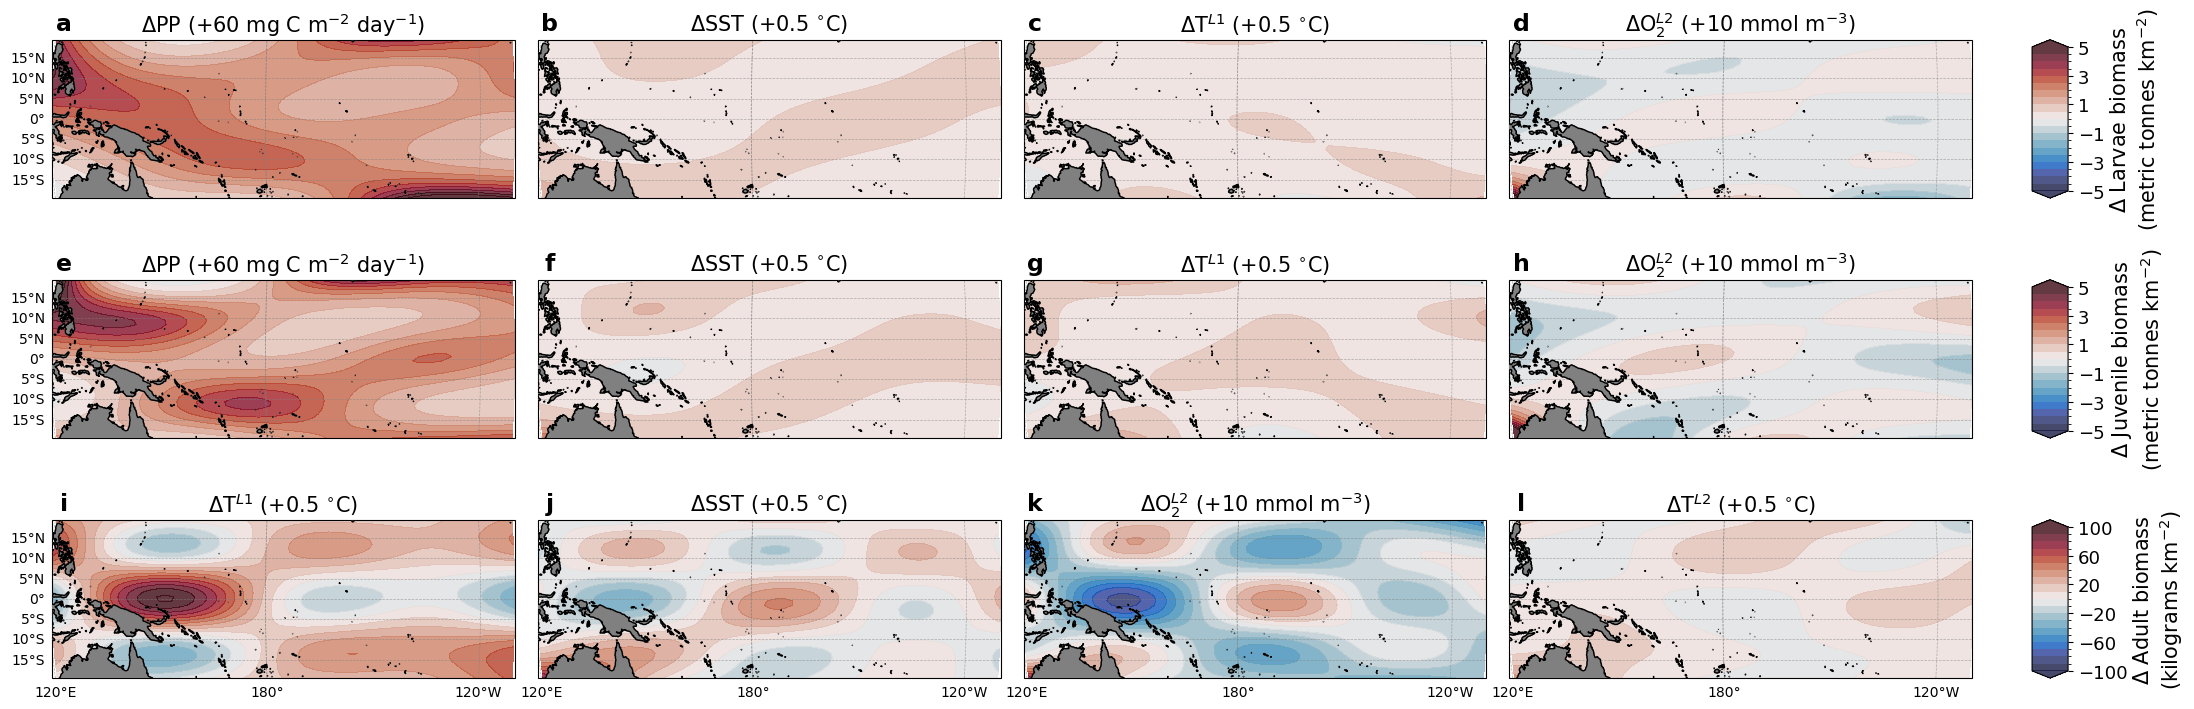

In [13]:
%%time

proj = ccrs.Robinson(central_longitude=205)

fstic = 13
fslab = 15

colmap = lighten(cmo.balance, 0.8)
levs1 = np.arange(-10,11,1)*0.5
norm1 = mcolors.BoundaryNorm(levs1, ncolors=256)
levs2 = np.arange(-10,11,1)*10
norm2 = mcolors.BoundaryNorm(levs2, ncolors=256)

fig = plt.figure(figsize=(24,8))
gs = GridSpec(3,4)

ax1 = plt.subplot(gs[0,0], projection=proj)
ax2 = plt.subplot(gs[0,1], projection=proj)
ax3 = plt.subplot(gs[0,2], projection=proj)
ax4 = plt.subplot(gs[0,3], projection=proj)
ax5 = plt.subplot(gs[1,0], projection=proj)
ax6 = plt.subplot(gs[1,1], projection=proj)
ax7 = plt.subplot(gs[1,2], projection=proj)
ax8 = plt.subplot(gs[1,3], projection=proj)
ax9 = plt.subplot(gs[2,0], projection=proj)
ax10 = plt.subplot(gs[2,1], projection=proj)
ax11 = plt.subplot(gs[2,2], projection=proj)
ax12 = plt.subplot(gs[2,3], projection=proj)

p1 = ax1.contourf(lons, lats, ds_larvae_perturb_PP['delta_eff'].sel(delta_mult=1).mean(dim='season_num').T, transform=ccrs.PlateCarree(), cmap=colmap, norm=norm1, levels=levs1, extend='both')
p2 = ax2.contourf(lons, lats, ds_larvae_perturb_SST['delta_eff'].sel(delta_mult=1).mean(dim='season_num').T, transform=ccrs.PlateCarree(), cmap=colmap, norm=norm1, levels=levs1, extend='both')
p3 = ax3.contourf(lons, lats, ds_larvae_perturb_TL1['delta_eff'].sel(delta_mult=1).mean(dim='season_num').T, transform=ccrs.PlateCarree(), cmap=colmap, norm=norm1, levels=levs1, extend='both')
p4 = ax4.contourf(lons, lats, ds_larvae_perturb_OL2['delta_eff'].sel(delta_mult=1).mean(dim='season_num').T, transform=ccrs.PlateCarree(), cmap=colmap, norm=norm1, levels=levs1, extend='both')

p5 = ax5.contourf(lons, lats, ds_juvenile_perturb_PP['delta_eff'].sel(delta_mult=1).mean(dim='season_num').T, transform=ccrs.PlateCarree(), cmap=colmap, norm=norm1, levels=levs1, extend='both')
p6 = ax6.contourf(lons, lats, ds_juvenile_perturb_SST['delta_eff'].sel(delta_mult=1).mean(dim='season_num').T, transform=ccrs.PlateCarree(), cmap=colmap, norm=norm1, levels=levs1, extend='both')
p7 = ax7.contourf(lons, lats, ds_juvenile_perturb_TL1['delta_eff'].sel(delta_mult=1).mean(dim='season_num').T, transform=ccrs.PlateCarree(), cmap=colmap, norm=norm1, levels=levs1, extend='both')
p8 = ax8.contourf(lons, lats, ds_juvenile_perturb_OL2['delta_eff'].sel(delta_mult=1).mean(dim='season_num').T, transform=ccrs.PlateCarree(), cmap=colmap, norm=norm1, levels=levs1, extend='both')

p9 = ax9.contourf(lons, lats, ds_adult_perturb_TL1['delta_eff'].sel(delta_mult=1).mean(dim='season_num').T, transform=ccrs.PlateCarree(), cmap=colmap, norm=norm2, levels=levs2, extend='both')
p10 = ax10.contourf(lons, lats, ds_adult_perturb_SST['delta_eff'].sel(delta_mult=1).mean(dim='season_num').T, transform=ccrs.PlateCarree(), cmap=colmap, norm=norm2, levels=levs2, extend='both')
p11 = ax11.contourf(lons, lats, ds_adult_perturb_OL2['delta_eff'].sel(delta_mult=1).mean(dim='season_num').T, transform=ccrs.PlateCarree(), cmap=colmap, norm=norm2, levels=levs2, extend='both')
p12 = ax12.contourf(lons, lats, ds_adult_perturb_TL2['delta_eff'].sel(delta_mult=1).mean(dim='season_num').T, transform=ccrs.PlateCarree(), cmap=colmap, norm=norm2, levels=levs2, extend='both')

ax1.add_feature(cfeature.LAND, color='grey', zorder=3)
ax1.add_feature(cfeature.COASTLINE, color='k', zorder=4)
ax2.add_feature(cfeature.LAND, color='grey', zorder=3)
ax2.add_feature(cfeature.COASTLINE, color='k', zorder=4)
ax3.add_feature(cfeature.LAND, color='grey', zorder=3)
ax3.add_feature(cfeature.COASTLINE, color='k', zorder=4)
ax4.add_feature(cfeature.LAND, color='grey', zorder=3)
ax4.add_feature(cfeature.COASTLINE, color='k', zorder=4)
ax5.add_feature(cfeature.LAND, color='grey', zorder=3)
ax5.add_feature(cfeature.COASTLINE, color='k', zorder=4)
ax6.add_feature(cfeature.LAND, color='grey', zorder=3)
ax6.add_feature(cfeature.COASTLINE, color='k', zorder=4)
ax7.add_feature(cfeature.LAND, color='grey', zorder=3)
ax7.add_feature(cfeature.COASTLINE, color='k', zorder=4)
ax8.add_feature(cfeature.LAND, color='grey', zorder=3)
ax8.add_feature(cfeature.COASTLINE, color='k', zorder=4)
ax9.add_feature(cfeature.LAND, color='grey', zorder=3)
ax9.add_feature(cfeature.COASTLINE, color='k', zorder=4)
ax10.add_feature(cfeature.LAND, color='grey', zorder=3)
ax10.add_feature(cfeature.COASTLINE, color='k', zorder=4)
ax11.add_feature(cfeature.LAND, color='grey', zorder=3)
ax11.add_feature(cfeature.COASTLINE, color='k', zorder=4)
ax12.add_feature(cfeature.LAND, color='grey', zorder=3)
ax12.add_feature(cfeature.COASTLINE, color='k', zorder=4)

gl1 = ax1.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.6, linestyle='--')
gl2 = ax2.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.6, linestyle='--')
gl3 = ax3.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.6, linestyle='--')
gl4 = ax4.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.6, linestyle='--')
gl5 = ax5.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.6, linestyle='--')
gl6 = ax6.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.6, linestyle='--')
gl7 = ax7.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.6, linestyle='--')
gl8 = ax8.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.6, linestyle='--')
gl9 = ax9.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.6, linestyle='--')
gl10 = ax10.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.6, linestyle='--')
gl11 = ax11.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.6, linestyle='--')
gl12 = ax12.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.6, linestyle='--')

gl1.top_labels = False; gl1.right_labels = False; gl1.bottom_labels = False
gl2.top_labels = False; gl2.right_labels = False; gl2.bottom_labels = False; gl2.left_labels = False
gl3.top_labels = False; gl3.right_labels = False; gl3.bottom_labels = False; gl3.left_labels = False
gl4.top_labels = False; gl4.right_labels = False; gl4.bottom_labels = False; gl4.left_labels = False
gl5.top_labels = False; gl5.right_labels = False; gl5.bottom_labels = False
gl6.top_labels = False; gl6.right_labels = False; gl6.bottom_labels = False; gl6.left_labels = False
gl7.top_labels = False; gl7.right_labels = False; gl7.bottom_labels = False; gl7.left_labels = False
gl8.top_labels = False; gl8.right_labels = False; gl8.bottom_labels = False; gl8.left_labels = False
gl9.top_labels = False; gl9.right_labels = False; 
gl10.top_labels = False; gl10.right_labels = False; gl10.left_labels = False
gl11.top_labels = False; gl11.right_labels = False; gl11.left_labels = False
gl12.top_labels = False; gl12.right_labels = False; gl12.left_labels = False

xx = 0.5; yy=1.1
plt.text(xx,yy,"$\Delta$PP (+60 mg C m$^{-2}$ day$^{-1}$)", fontsize=fslab, ha='center', va='center', transform=ax1.transAxes)
plt.text(xx,yy,"$\Delta$SST (+0.5 $^{\circ}$C)", fontsize=fslab, ha='center', va='center', transform=ax2.transAxes)
plt.text(xx,yy,"$\Delta$T$^{L1}$ (+0.5 $^{\circ}$C)", fontsize=fslab, ha='center', va='center', transform=ax3.transAxes)
plt.text(xx,yy,"$\Delta$O$_2^{L2}$ (+10 mmol m$^{-3}$)", fontsize=fslab, ha='center', va='center', transform=ax4.transAxes)

plt.text(xx,yy,"$\Delta$PP (+60 mg C m$^{-2}$ day$^{-1}$)", fontsize=fslab, ha='center', va='center', transform=ax5.transAxes)
plt.text(xx,yy,"$\Delta$SST (+0.5 $^{\circ}$C)", fontsize=fslab, ha='center', va='center', transform=ax6.transAxes)
plt.text(xx,yy,"$\Delta$T$^{L1}$ (+0.5 $^{\circ}$C)", fontsize=fslab, ha='center', va='center', transform=ax7.transAxes)
plt.text(xx,yy,"$\Delta$O$_2^{L2}$ (+10 mmol m$^{-3}$)", fontsize=fslab, ha='center', va='center', transform=ax8.transAxes)

plt.text(xx,yy,"$\Delta$T$^{L1}$ (+0.5 $^{\circ}$C)", fontsize=fslab, ha='center', va='center', transform=ax9.transAxes)
plt.text(xx,yy,"$\Delta$SST (+0.5 $^{\circ}$C)", fontsize=fslab, ha='center', va='center', transform=ax10.transAxes)
plt.text(xx,yy,"$\Delta$O$_2^{L2}$ (+10 mmol m$^{-3}$)", fontsize=fslab, ha='center', va='center', transform=ax11.transAxes)
plt.text(xx,yy,"$\Delta$T$^{L2}$ (+0.5 $^{\circ}$C)", fontsize=fslab, ha='center', va='center', transform=ax12.transAxes)

plt.subplots_adjust(wspace=0.05, hspace=0.0, left=0.05, right=0.85, bottom=0.05, top=0.95)

xx = 0.025
ax4pos = ax4.get_position()
ax8pos = ax8.get_position()
ax12pos = ax12.get_position()
cbax1 = fig.add_axes([ax4pos.x1 + xx, ax4pos.y0, 0.015, ax4pos.y1 - ax4pos.y0])
cbax2 = fig.add_axes([ax8pos.x1 + xx, ax8pos.y0, 0.015, ax8pos.y1 - ax8pos.y0])
cbax3 = fig.add_axes([ax12pos.x1 + xx, ax12pos.y0, 0.015, ax12pos.y1 - ax12pos.y0])

cbar1 = plt.colorbar(p1, cax=cbax1, orientation='vertical', ticks=levs1[::4])
cbar1.ax.tick_params(labelsize=fstic)
cbar1.ax.set_ylabel("$\Delta$ Larvae biomass\n(metric tonnes km$^{-2}$)", fontsize=fslab)

cbar2 = plt.colorbar(p5, cax=cbax2, orientation='vertical', ticks=levs1[::4])
cbar2.ax.tick_params(labelsize=fstic)
cbar2.ax.set_ylabel("$\Delta$ Juvenile biomass\n(metric tonnes km$^{-2}$)", fontsize=fslab)

cbar3 = plt.colorbar(p9, cax=cbax3, orientation='vertical', ticks=levs2[::4])
cbar3.ax.tick_params(labelsize=fstic)
cbar3.ax.set_ylabel("$\Delta$ Adult biomass\n(kilograms km$^{-2}$)", fontsize=fslab)

xx = 0.025; yy = 1.1
plt.text(xx,yy,"a", fontweight="bold", fontsize=fslab+2, va='center', ha='center', transform=ax1.transAxes)
plt.text(xx,yy,"b", fontweight="bold", fontsize=fslab+2, va='center', ha='center', transform=ax2.transAxes)
plt.text(xx,yy,"c", fontweight="bold", fontsize=fslab+2, va='center', ha='center', transform=ax3.transAxes)
plt.text(xx,yy,"d", fontweight="bold", fontsize=fslab+2, va='center', ha='center', transform=ax4.transAxes)
plt.text(xx,yy,"e", fontweight="bold", fontsize=fslab+2, va='center', ha='center', transform=ax5.transAxes)
plt.text(xx,yy,"f", fontweight="bold", fontsize=fslab+2, va='center', ha='center', transform=ax6.transAxes)
plt.text(xx,yy,"g", fontweight="bold", fontsize=fslab+2, va='center', ha='center', transform=ax7.transAxes)
plt.text(xx,yy,"h", fontweight="bold", fontsize=fslab+2, va='center', ha='center', transform=ax8.transAxes)
plt.text(xx,yy,"i", fontweight="bold", fontsize=fslab+2, va='center', ha='center', transform=ax9.transAxes)
plt.text(xx,yy,"j", fontweight="bold", fontsize=fslab+2, va='center', ha='center', transform=ax10.transAxes)
plt.text(xx,yy,"k", fontweight="bold", fontsize=fslab+2, va='center', ha='center', transform=ax11.transAxes)
plt.text(xx,yy,"l", fontweight="bold", fontsize=fslab+2, va='center', ha='center', transform=ax12.transAxes)



In [14]:
%%time
    
fig.savefig("./figures/Spatial_effects_perturb.png", dpi=300, bbox_inches='tight')
fig.savefig("./figures/Spatial_effects_perturb_transparent.png", dpi=300, bbox_inches='tight', transparent=True)


CPU times: user 19.4 s, sys: 114 ms, total: 19.5 s
Wall time: 19.8 s


### Visualise the typical standard deviation of each predictor at each location

CPU times: user 1.26 s, sys: 237 ms, total: 1.5 s
Wall time: 1.25 s


/g/data/es60/pjb581/miniforge3/envs/pyEMD_env/lib/python3.10/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


Text(0.025, 1.05, 'e')

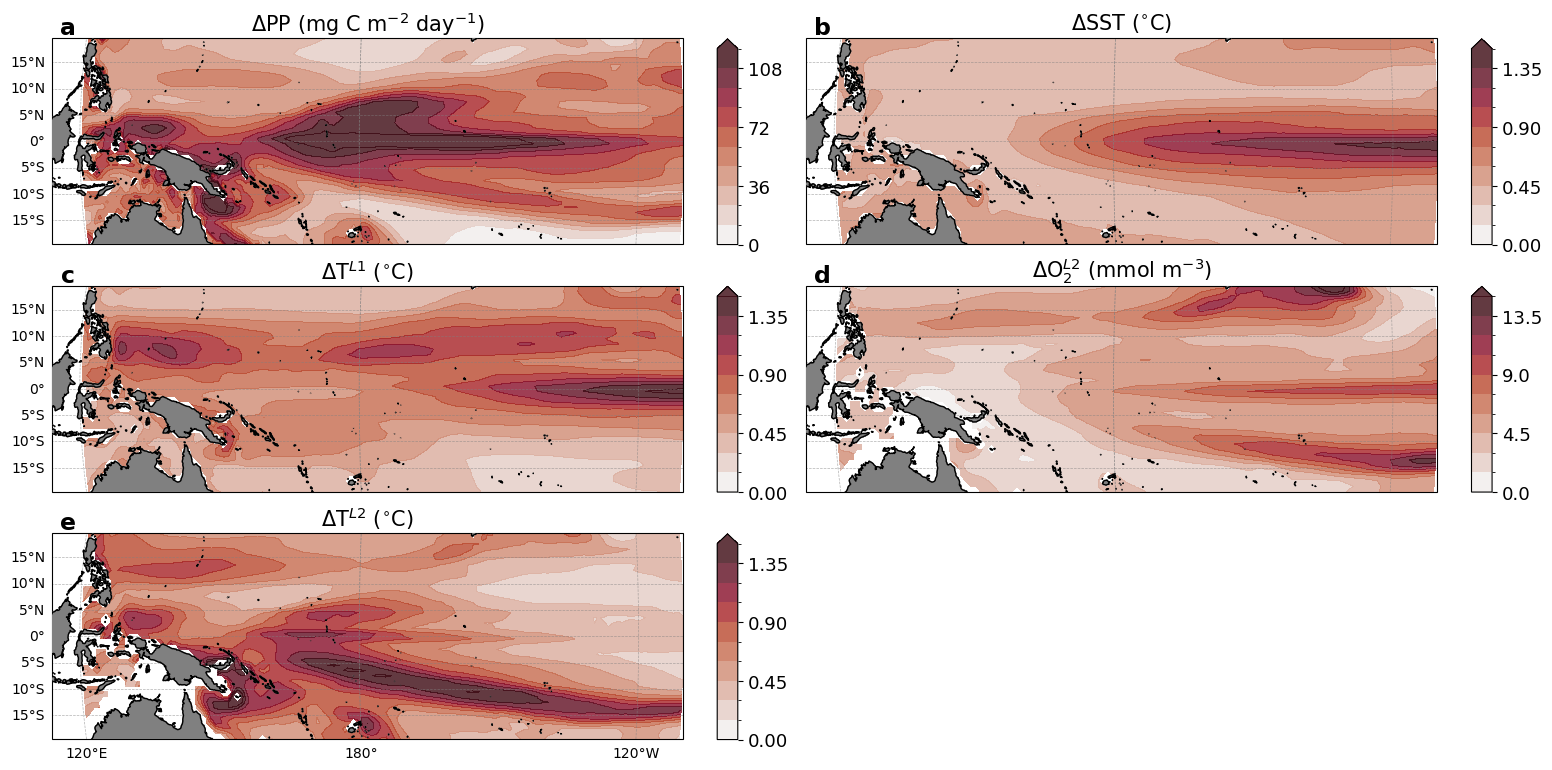

In [25]:
%%time

proj = ccrs.Robinson(central_longitude=205)

fstic = 13
fslab = 15

colmap = lighten(cmo.amp, 0.8)

levs1 = np.arange(0,11,1)*1.0*12 # PP
levs2 = np.arange(0,11,1)*0.1*1.5 # SST
levs3 = np.arange(0,11,1)*0.1*1.5 # TL1
levs4 = np.arange(0,11,1)*1.0*1.5 # O2L2
levs5 = np.arange(0,11,1)*0.1*1.5 # TL2

norm1 = mcolors.BoundaryNorm(levs1, ncolors=256)
norm2 = mcolors.BoundaryNorm(levs2, ncolors=256)
norm3 = mcolors.BoundaryNorm(levs3, ncolors=256)
norm4 = mcolors.BoundaryNorm(levs4, ncolors=256)
norm5 = mcolors.BoundaryNorm(levs5, ncolors=256)

fig = plt.figure(figsize=(16,8))
gs = GridSpec(3,2)

ax1 = plt.subplot(gs[0,0], projection=proj)
ax2 = plt.subplot(gs[0,1], projection=proj)
ax3 = plt.subplot(gs[1,0], projection=proj)
ax4 = plt.subplot(gs[1,1], projection=proj)
ax5 = plt.subplot(gs[2,0], projection=proj)
#ax6 = plt.subplot(gs[2,1], projection=proj)

p1 = ax1.contourf(lons, lats, ds_larvae_PP['delta_value'].sel(delta_mult=1).mean(dim='season_num').T*12, transform=ccrs.PlateCarree(), cmap=colmap, norm=norm1, levels=levs1, extend='max')
p2 = ax2.contourf(lons, lats, ds_larvae_SST['delta_value'].sel(delta_mult=1).mean(dim='season_num').T, transform=ccrs.PlateCarree(), cmap=colmap, norm=norm2, levels=levs2, extend='max')
p3 = ax3.contourf(lons, lats, ds_larvae_TL1['delta_value'].sel(delta_mult=1).mean(dim='season_num').T, transform=ccrs.PlateCarree(), cmap=colmap, norm=norm3, levels=levs3, extend='max')
p4 = ax4.contourf(lons, lats, ds_larvae_OL2['delta_value'].sel(delta_mult=1).mean(dim='season_num').T * 44.661, transform=ccrs.PlateCarree(), cmap=colmap, norm=norm4, levels=levs4, extend='max')
p5 = ax5.contourf(lons, lats, ds_adult_TL2['delta_value'].sel(delta_mult=1).mean(dim='season_num').T, transform=ccrs.PlateCarree(), cmap=colmap, norm=norm5, levels=levs5, extend='max')

ax1.add_feature(cfeature.LAND, color='grey', zorder=3)
ax1.add_feature(cfeature.COASTLINE, color='k', zorder=4)
ax2.add_feature(cfeature.LAND, color='grey', zorder=3)
ax2.add_feature(cfeature.COASTLINE, color='k', zorder=4)
ax3.add_feature(cfeature.LAND, color='grey', zorder=3)
ax3.add_feature(cfeature.COASTLINE, color='k', zorder=4)
ax4.add_feature(cfeature.LAND, color='grey', zorder=3)
ax4.add_feature(cfeature.COASTLINE, color='k', zorder=4)
ax5.add_feature(cfeature.LAND, color='grey', zorder=3)
ax5.add_feature(cfeature.COASTLINE, color='k', zorder=4)

gl1 = ax1.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.6, linestyle='--')
gl2 = ax2.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.6, linestyle='--')
gl3 = ax3.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.6, linestyle='--')
gl4 = ax4.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.6, linestyle='--')
gl5 = ax5.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.6, linestyle='--')

gl1.top_labels = False; gl1.right_labels = False; gl1.bottom_labels = False
gl2.top_labels = False; gl2.right_labels = False; gl2.bottom_labels = False; gl2.left_labels = False
gl3.top_labels = False; gl3.right_labels = False; gl3.bottom_labels = False
gl4.top_labels = False; gl4.right_labels = False; gl4.bottom_labels = False; gl4.left_labels = False
gl5.top_labels = False; gl5.right_labels = False
#gl6.top_labels = False; gl6.right_labels = False

xx = 0.5; yy=1.075
plt.text(xx,yy,"$\Delta$PP (mg C m$^{-2}$ day$^{-1}$)", fontsize=fslab, ha='center', va='center', transform=ax1.transAxes)
plt.text(xx,yy,"$\Delta$SST ($^{\circ}$C)", fontsize=fslab, ha='center', va='center', transform=ax2.transAxes)
plt.text(xx,yy,"$\Delta$T$^{L1}$ ($^{\circ}$C)", fontsize=fslab, ha='center', va='center', transform=ax3.transAxes)
plt.text(xx,yy,"$\Delta$O$_2^{L2}$ (mmol m$^{-3}$)", fontsize=fslab, ha='center', va='center', transform=ax4.transAxes)
plt.text(xx,yy,"$\Delta$T$^{L2}$ ($^{\circ}$C)", fontsize=fslab, ha='center', va='center', transform=ax5.transAxes)

plt.subplots_adjust(wspace=0.1, hspace=0.1, left=0.05, right=0.95, bottom=0.05, top=0.95)

cbar1 = plt.colorbar(p1, ax=ax1, orientation='vertical', ticks=levs1[::3], fraction=0.03, aspect=10)
cbar2 = plt.colorbar(p2, ax=ax2, orientation='vertical', ticks=levs2[::3], fraction=0.03, aspect=10)
cbar3 = plt.colorbar(p3, ax=ax3, orientation='vertical', ticks=levs3[::3], fraction=0.03, aspect=10)
cbar4 = plt.colorbar(p4, ax=ax4, orientation='vertical', ticks=levs4[::3], fraction=0.03, aspect=10)
cbar5 = plt.colorbar(p5, ax=ax5, orientation='vertical', ticks=levs5[::3], fraction=0.03, aspect=10)

cbar1.ax.tick_params(labelsize=fstic)
cbar2.ax.tick_params(labelsize=fstic)
cbar3.ax.tick_params(labelsize=fstic)
cbar4.ax.tick_params(labelsize=fstic)
cbar5.ax.tick_params(labelsize=fstic)

xx = 0.025; yy = 1.05
plt.text(xx,yy,"a", fontweight="bold", fontsize=fslab+2, va='center', ha='center', transform=ax1.transAxes)
plt.text(xx,yy,"b", fontweight="bold", fontsize=fslab+2, va='center', ha='center', transform=ax2.transAxes)
plt.text(xx,yy,"c", fontweight="bold", fontsize=fslab+2, va='center', ha='center', transform=ax3.transAxes)
plt.text(xx,yy,"d", fontweight="bold", fontsize=fslab+2, va='center', ha='center', transform=ax4.transAxes)
plt.text(xx,yy,"e", fontweight="bold", fontsize=fslab+2, va='center', ha='center', transform=ax5.transAxes)



In [26]:

fig.savefig("./figures/Spatial_effects_predictorSTDs.png", dpi=300, bbox_inches='tight')
fig.savefig("./figures/Spatial_effects_predictorSTDs_transparent.png", dpi=300, bbox_inches='tight', transparent=True)



### Load SST and TL1 data

In [11]:
%%time

sst = xr.open_dataset("/g/data/es60/SEAPODYM/forcings_netCDF/ipo_jra55np_1x30d_sst_1958_2022.nc")['sst']
T_L1 = xr.open_dataset("/g/data/es60/SEAPODYM/forcings_netCDF/ipo_jra55np_1x30d_T_L1_1958_2022.nc")['T_L1']


CPU times: user 45.6 ms, sys: 15 ms, total: 60.7 ms
Wall time: 45 ms


### Check to see how these are correlated

In [12]:
%%time

r_sst_TL1 = xr.corr(sst, T_L1, dim='time')
r_sst_TL1


CPU times: user 944 ms, sys: 479 ms, total: 1.42 s
Wall time: 1.4 s


<xarray.DataArray (lat: 120, lon: 260)> Size: 125kB
array([[0.9272201 , 0.9220606 , 0.91796184, ..., 0.93997544, 0.93961877,
        0.9411042 ],
       [0.9499825 , 0.9447388 , 0.93915594, ..., 0.94372493, 0.9545399 ,
        0.9606822 ],
       [0.96426105, 0.96127075, 0.9574099 , ..., 0.96794116, 0.97314095,
        0.97758514],
       ...,
       [       nan,        nan,        nan, ...,        nan,        nan,
               nan],
       [       nan,        nan,        nan, ...,        nan,        nan,
               nan],
       [       nan,        nan,        nan, ...,        nan,        nan,
               nan]], shape=(120, 260), dtype=float32)
Coordinates:
  * lon      (lon) float64 2kB 30.5 31.5 32.5 33.5 ... 286.5 287.5 288.5 289.5
  * lat      (lat) float64 960B -58.5 -57.5 -56.5 -55.5 ... 57.5 58.5 59.5 60.5

/g/data/es60/pjb581/miniforge3/envs/pyEMD_env/lib/python3.10/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


CPU times: user 2.9 s, sys: 503 ms, total: 3.41 s
Wall time: 2.83 s


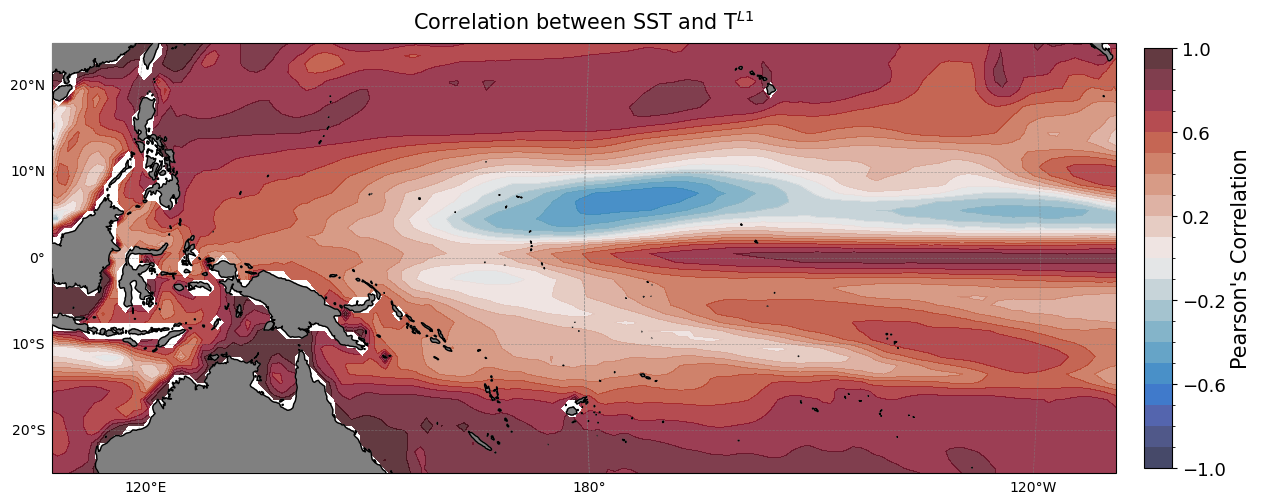

In [13]:
%%time

proj = ccrs.Robinson(central_longitude=205)
fstic = 13
fslab = 15
colmap = lighten(cmo.balance, 0.8)
levs1 = np.arange(-10,11,1)*0.1
norm1 = mcolors.BoundaryNorm(levs1, ncolors=256)

fig = plt.figure(figsize=(14,6))
gs = GridSpec(1,1)
ax1 = plt.subplot(gs[0,0], projection=proj)
p1 = ax1.contourf(r_sst_TL1.coords['lon'], r_sst_TL1.coords['lat'], r_sst_TL1, transform=ccrs.PlateCarree(), cmap=colmap, norm=norm1, levels=levs1, extend='neither')
ax1.add_feature(cfeature.LAND, color='grey', zorder=3)
ax1.add_feature(cfeature.COASTLINE, color='k', zorder=4)
gl1 = ax1.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.6, linestyle='--')
gl1.top_labels = False; gl1.right_labels = False

xx = 0.5; yy=1.05
plt.text(xx,yy,"Correlation between SST and T$^{L1}$", fontsize=fslab, ha='center', va='center', transform=ax1.transAxes)
plt.subplots_adjust(wspace=0.1, hspace=0.1, left=0.1, right=0.9, bottom=0.1)

cbar1 = plt.colorbar(p1, ax=ax1, orientation='vertical', ticks=levs1[::4], aspect=15, fraction=0.025, pad=0.025)
cbar1.ax.tick_params(labelsize=fstic)
cbar1.ax.set_ylabel("Pearson's Correlation", fontsize=fslab)

ax1.set_extent([110,250,-25,25], crs=ccrs.PlateCarree())

fig.savefig("./figures/Correlation_SST_TL1.png", dpi=300, bbox_inches='tight')




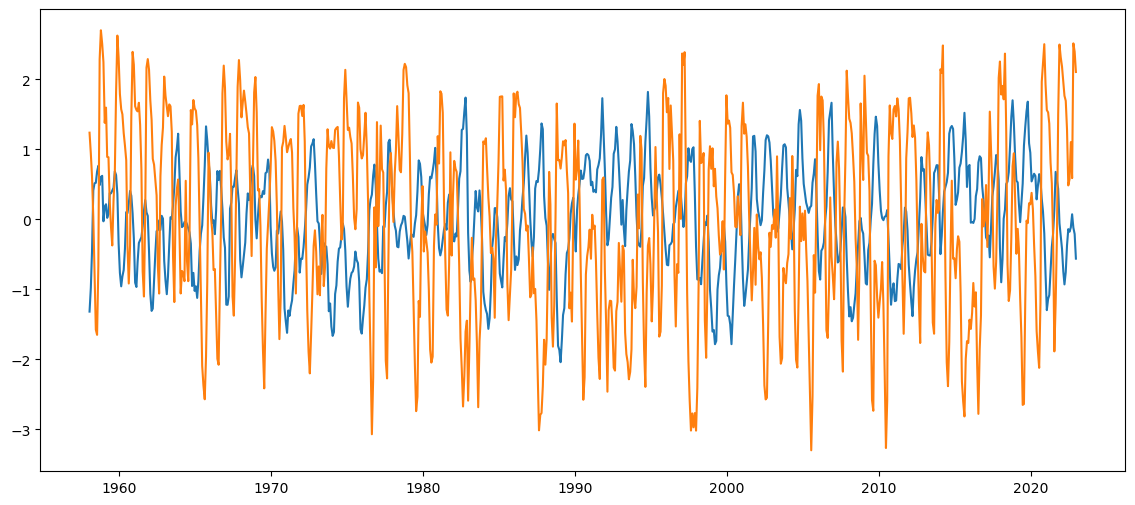

In [14]:
sst_tmp1 = sst.sel(lon=182.0, lat=5.0, method='nearest')
TL1_tmp1 = T_L1.sel(lon=182.0, lat=5.0, method='nearest')

plt.figure(figsize=(14,6))
plt.plot(sst.coords['time'], sst_tmp1 - sst_tmp1.mean(dim='time'))
plt.plot(T_L1.coords['time'], TL1_tmp1 - TL1_tmp1.mean(dim='time'))